In [2]:
import pandas as pd

from filter_data import *


In [68]:
l_min = 3
max_diff = 3
c_thresh = 0.9

csv_read_path = os.path.join(project_root, "data", "processed", "integrated.csv")
csv_semi_write_path = os.path.join(project_root, "data", "processed", f"semi_processed{l_min}.csv")

df = pd.read_csv(csv_read_path, encoding='utf-8')

feature_adder = Feature_adder(df)
for feature in ["temperature", "humidity", "dew", "surface_pressure"]:
    for hour in [1, 5]:
        feature_adder.create_feature_with_delay(feature, hour)

feature_adder.create_feature_with_delay("generation", 24)

feature_adder.filter1()

feature_adder.filter2(l_min=l_min, max_diff=max_diff)


2025-09-29 15:19:59 - feature_adder - INFO - 34.26% of rows have been chosen by filter1
2025-09-29 15:20:07 - feature_adder - INFO - 61.10% of rows have been chosen by filter2


In [69]:
fa_df = feature_adder.df
fa_df = fa_df[fa_df['is_good_peak'] >= 1]

In [71]:
time_ranges = feature_adder.time_ranges_by_name_code

In [70]:
power_plants = fa_df[['name', 'code']].drop_duplicates()

In [72]:
time_ranges_list = []
for _, row in power_plants.iterrows():
    time_ranges_list += time_ranges[row['name'], row['code']]

In [73]:
interval_length = [e - s + pd.Timedelta(hours = 1) for s,e in time_ranges_list]
interval_length = [td.total_seconds() / 3600 for td in interval_length]

In [74]:
import numpy as np
values, counts = np.unique(interval_length, return_counts=True)

In [76]:
for value, count in zip(values, counts):
    print("value: ", value, "count: ", count)

value:  3.0 count:  3356
value:  4.0 count:  5839
value:  5.0 count:  1394
value:  6.0 count:  993
value:  7.0 count:  733
value:  8.0 count:  640
value:  9.0 count:  556
value:  10.0 count:  437
value:  11.0 count:  402
value:  12.0 count:  237
value:  13.0 count:  256
value:  14.0 count:  308
value:  15.0 count:  474
value:  16.0 count:  824
value:  17.0 count:  1071
value:  18.0 count:  2991


In [96]:
cum_counts = counts.cumsum()

In [97]:
cum_counts = cum_counts * values

In [98]:
pcntg_counts = cum_counts / cum_counts[-1]

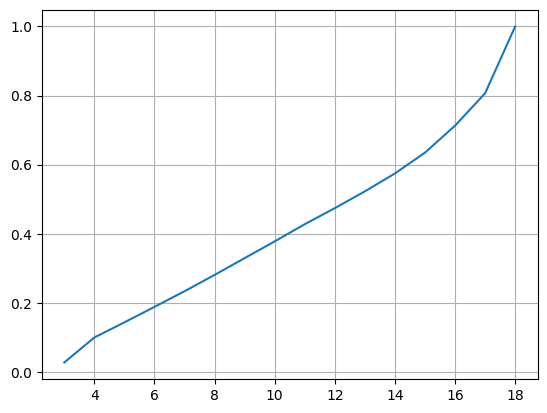

In [90]:
import matplotlib.pyplot as plt
plt.plot(values, pcntg_counts)
plt.grid()
plt.show()

In [80]:
max_diff = 3
c_thresh = 0.9
csv_read_path = os.path.join(project_root, "data", "processed", "integrated.csv")
df = pd.read_csv(csv_read_path, encoding='utf-8')
    
for l_min in range(3, 19):
    
    csv_semi_write_path = os.path.join(project_root, "data", "processed", f"semi_processed{l_min}.csv")
    
    feature_adder = Feature_adder(df)
    for feature in ["temperature", "humidity", "dew", "surface_pressure"]:
        for hour in [1, 5]:
            feature_adder.create_feature_with_delay(feature, hour)
    
    feature_adder.create_feature_with_delay("generation", 24)
    
    feature_adder.filter1()
    
    feature_adder.filter2(l_min=l_min, max_diff=max_diff)
    
    feature_adder.filter3("temperature_with_5_delay", c_thresh=c_thresh)
    feature_adder.add_interval_id()

    feature_adder.df.to_csv(csv_semi_write_path, index=False)


2025-09-29 15:22:24 - feature_adder - INFO - 34.26% of rows have been chosen by filter1
2025-09-29 15:22:31 - feature_adder - INFO - 61.10% of rows have been chosen by filter2
U:\ML_project\Bargh_ML\src\models\filter_data\feature_adder.py:201: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr_pearson, _ = pearsonr(arr1, arr2)
2025-09-29 15:22:48 - feature_adder - INFO - 52.91% of rows have been chosen by filter3
2025-09-29 15:23:29 - feature_adder - INFO - 34.35% of rows have been chosen by filter1
2025-09-29 15:23:36 - feature_adder - INFO - 57.58% of rows have been chosen by filter2
2025-09-29 15:23:51 - feature_adder - INFO - 53.45% of rows have been chosen by filter3
2025-09-29 15:24:31 - feature_adder - INFO - 34.43% of rows have been chosen by filter1
2025-09-29 15:24:37 - feature_adder - INFO - 49.36% of rows have been chosen by filter2
2025-09-29 15:24:48 - feature_adder - INFO - 54.50% of rows have been chosen by filter3
2025-

In [20]:
csv_read_path = os.path.join(project_root, "data", "processed", "semi_processed.csv")
df = pd.read_csv(csv_read_path, encoding='utf-8')

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 828211 entries, 0 to 828210
Data columns (total 37 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   id                             828211 non-null  int64  
 1   name                           828211 non-null  object 
 2   code                           828211 non-null  object 
 3   date                           828211 non-null  object 
 4   hour                           828211 non-null  int64  
 5   temperature                    828211 non-null  float64
 6   humidity                       828211 non-null  float64
 7   dew                            828211 non-null  float64
 8   apparent_temperature           828211 non-null  float64
 9   precipitation                  828211 non-null  float64
 10  rain                           828211 non-null  float64
 11  snow                           828211 non-null  float64
 12  surface_pressure              

In [22]:
power_plants = df[['name', 'code']].drop_duplicates()

In [15]:
len(power_plants)

108

In [16]:
df = df.dropna()
power_plants = df[['name', 'code']].drop_duplicates()

In [17]:
len(power_plants)

52

In [23]:
df.columns

Index(['id', 'name', 'code', 'date', 'hour', 'temperature', 'humidity', 'dew',
       'apparent_temperature', 'precipitation', 'rain', 'snow',
       'surface_pressure', 'evapotransporation', 'wind_speed',
       'wind_direction', 'value', 'forecast', 'generation', 'declare',
       'status', 'require', 'datetime', 'season', 'day_of_week', 'month',
       'is_good_peak', 'temperature_with_1_delay', 'temperature_with_5_delay',
       'humidity_with_1_delay', 'humidity_with_5_delay', 'dew_with_1_delay',
       'dew_with_5_delay', 'surface_pressure_with_1_delay',
       'surface_pressure_with_5_delay', 'generation_with_24_delay',
       'interval_id'],
      dtype='object')